# **Task Level (Beginner)**

1. The task at hand is to develop a practical solution for image
tagging by training a straightforward model. This model should
exhibit proficiency in categorizing images into elementary classes
like "cat," "dog," "car," etc., employing prominent libraries such as
TensorFlow or PyTorch. The overarching objective is to harness the
power of machine learning to create an effective and accessible
image classification system with real-world applicability across
various domains and use cases.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [ ]:
df= tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test)= df.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


In [ ]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

In [ ]:
x_train[0], y_train[0]

(array([[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],
 
        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],
 
        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],
 
        ...,
 
        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],
 
        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],
 
        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
  

The CIFAR-10 dataset contains images from 10 different classes:

*   **0**: airplane
*   **1**: automobile
*   **2**: bird
*   **3**: cat
*   **4**: deer
*   **5**: dog
*   **6**: frog
*   **7**: horse
*   **8**: ship
*   **9**: truck

**Visualizing the Dataset**

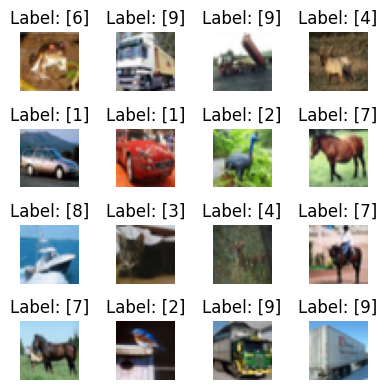

In [ ]:
plt.figure(figsize=(4,4))
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.imshow(x_train[i])
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.tight_layout()
plt.show()

## Data Preprocessing

In [ ]:
label_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

y_train_labels = np.array([label_names[label[0]] for label in y_train])
y_test_labels = np.array([label_names[label[0]] for label in y_test])

print("original y_train labels:\n", y_train[:5])
print("new y_train_labels:\n", y_train_labels[:5])

original y_train labels:
 [[6]
 [9]
 [9]
 [4]
 [1]]
new y_train_labels:
 ['frog' 'truck' 'truck' 'deer' 'automobile']


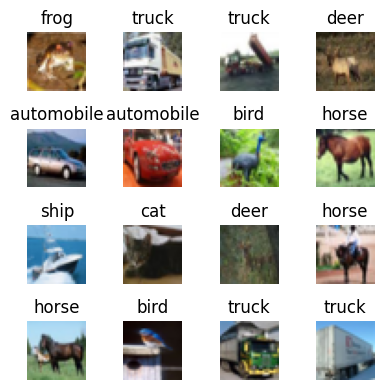

In [ ]:
plt.figure(figsize=(4,4))
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.imshow(x_train[i])
  plt.title(y_train_labels[i])
  plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Normalizing the image data by dividing by 255.0 to scale pixel values to a range of 0 to 1
x_train, x_test = x_train/255.0, x_test/255.0
y_train, y_test = y_train.flatten(), y_test.flatten()

## Model Architecture

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model

n_classes = len(set(y_train))  # number of classes

# input layer
input_layer = Input(shape=x_train[0].shape)

# First Convolutional Block
conv_layer = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
conv_layer = BatchNormalization()(conv_layer)
# Another Conv2D layer
conv_layer = Conv2D(32, (3,3), activation='relu', padding='same')(conv_layer)
# Batch Normalization
conv_layer = BatchNormalization()(conv_layer)
# MaxPooling reduces the spatial dimensions (height and width) of the output
conv_layer = MaxPooling2D((2,2))(conv_layer)
# Dropout layer, helps prevent overfitting
conv_layer = Dropout(0.2)(conv_layer)

# Second Convolutional Block
conv_layer = Conv2D(64, (3,3), activation='relu', padding='same')(conv_layer)
# Batch Normalization
conv_layer = BatchNormalization()(conv_layer)
# Another Conv2D layer
conv_layer = Conv2D(64, (3,3), activation='relu', padding='same')(conv_layer)
# Batch Normalization
conv_layer = BatchNormalization()(conv_layer)
# MaxPooling
conv_layer = MaxPooling2D((2,2))(conv_layer)
# Dropout
conv_layer = Dropout(0.2)(conv_layer)

conv_layer = Flatten()(conv_layer)
# Fully connected Dense layer with 1024 units and ReLU activation
conv_layer = Dense(1024, activation='relu')(conv_layer)
conv_layer = Dropout(0.2)(conv_layer)
# Output Dense layer with n_classes (number of classes) and softmax activation
output_layer = Dense(n_classes, activation='softmax')(conv_layer)

model_1 = Model(input_layer, output_layer)

In [ ]:
model_1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,814,976 (48.89 MB)

 Trainable params: 4,271,530 (16.29 MB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 8,543,062 (32.59 MB)

## Model Training

In [ ]:
model_1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'],)
with tf.device('/GPU:0'):
  model_1.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.5223 - loss: 1.4118 - val_accuracy: 0.6055 - val_loss: 1.1299
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6725 - loss: 0.9399 - val_accuracy: 0.6994 - val_loss: 0.8695
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7308 - loss: 0.7740 - val_accuracy: 0.7346 - val_loss: 0.7630
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7702 - loss: 0.6614 - val_accuracy: 0.7559 - val_loss: 0.7349
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8012 - loss: 0.5740 - val_accuracy: 0.7627 - val_loss: 0.7393
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8368 - loss: 0.4749 - val_accuracy: 0.7772 - val_loss: 0.6749
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8635 - loss: 0.3951 - val_accuracy: 0.7864 - val_loss: 0.7195
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8855 - loss: 

## Model Evaluation

In [ ]:
acc = model_1.evaluate(x_test, y_test)
print(f"Testing accuracy: {acc[1]}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8125 - loss: 1.1235
Testing accuracy: 0.8125


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


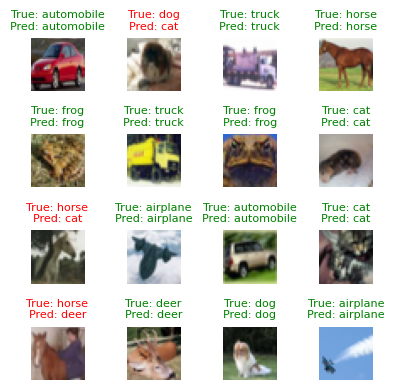

In [ ]:
num_images = 16
random_indices = np.random.choice(len(x_test), num_images, replace=False)

x_test_sample = x_test[random_indices]
y_test_sample = y_test[random_indices]
y_test_labels_sample = y_test_labels[random_indices]

# make predictions on the selected images
pred = model_1.predict(x_test_sample)
pred_classes = np.argmax(pred, axis=1)
pred_labels = np.array([label_names[idx] for idx in pred_classes])

# plot the images with true and predicted labels
plt.figure(figsize=(4, 4))
for i in range(num_images):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_test_sample[i])
    color = "green" if pred_labels[i] == y_test_labels_sample[i] else "red"
    plt.title(f"True: {y_test_labels_sample[i]}\nPred: {pred_labels[i]}", color=color, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()